In [ ]:
import pandas as pd

deliveries=pd.read_csv("../raw/deliveries.csv")
deliveries.head

<bound method NDFrame.head of         match_id  inning           batting_team                 bowling_team  \
0         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
1         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
2         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
3         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
4         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
...          ...     ...                    ...                          ...   
260915   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260916   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260917   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260918   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260919   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   

        o

In [ ]:
powerplay_data=deliveries[deliveries['over']<=6].copy()

powerplay_data.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [4]:
powerplay_data['total_runs']=powerplay_data['batsman_runs']+powerplay_data['extra_runs']

In [5]:
powerplay_data.shape
powerplay_data['over'].unique()


array([0, 1, 2, 3, 4, 5, 6])

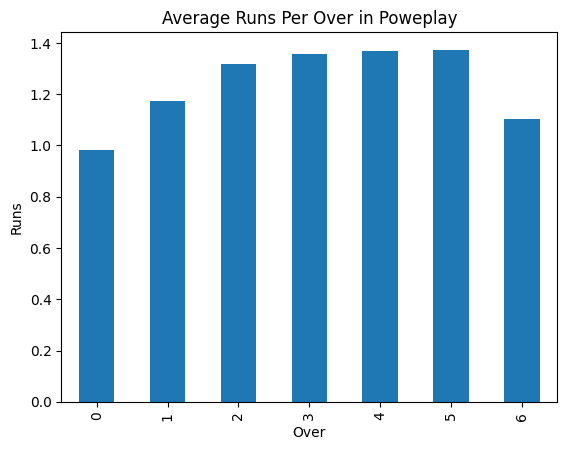

In [6]:
import matplotlib.pyplot as plt
runs_per_over=powerplay_data.groupby('over')['total_runs'].mean()

runs_per_over.plot(kind='bar')
plt.title("Average Runs Per Over in Poweplay")
plt.xlabel("Over")
plt.ylabel("Runs")
plt.show()

 Analyst's Insights 1:
--->Middle to later overs (specifically 3-5) of powerplay saw an upsurge in run-rate.
---> Indicating batsman taking charge after settling in the middle for an over or so.


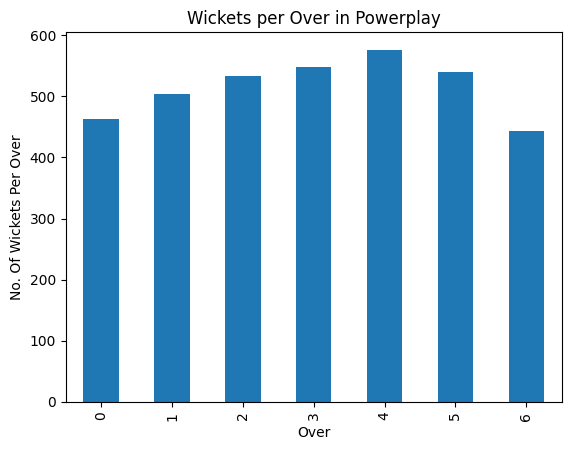

In [7]:
wickets=powerplay_data[powerplay_data['is_wicket']==1]
wickets_per_over=wickets.groupby('over').size()
wickets_per_over.plot(kind='bar')
plt.title("Wickets per Over in Powerplay")
plt.xlabel("Over")
plt.ylabel("No. Of Wickets Per Over")
plt.show()


Analyst's Insights 2:
--->While wickets falling in powerplay has a constant rate throughout yet a peak can be seen in the 4th over
--->This indicates that Batsman loose their wicket while taking risk 


In [8]:
pp_over=powerplay_data.groupby(['match_id','inning','over']).agg({
    'total_runs':'sum',
    'is_wicket':'sum'
}).reset_index()

pp_over.head()

,match_id,inning,over,total_runs,is_wicket
0,335982,1,0,3,0
1,335982,1,1,18,0
2,335982,1,2,6,0
3,335982,1,3,23,0
4,335982,1,4,10,0


In [11]:
pp_over=pp_over.merge(matches[['id','venue','team1','team2']],
left_on='match_id',right_on='id')
pp_over.head()



,match_id,inning,over,total_runs,is_wicket,id,venue,team1,team2
0,335982,1,0,3,0,335982,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders
1,335982,1,1,18,0,335982,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders
2,335982,1,2,6,0,335982,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders
3,335982,1,3,23,0,335982,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders
4,335982,1,4,10,0,335982,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders


In [12]:
pp_over.columns

Index(['match_id', 'inning', 'over', 'total_runs', 'is_wicket', 'id', 'venue',
       'team1', 'team2'],
      dtype='str')

In [10]:
matches=pd.read_csv("../raw/matches.csv")

In [13]:
pp_over['batting_team']=pp_over.apply(
    lambda row:row['team2'] if row['inning']==1 else row['team1'],
    axis=1
)

In [14]:
pp_over['bowling_team']=pp_over.apply(
    lambda row:row['team1'] if row['inning']==1 else row['team2'],
    axis=1
)

In [15]:
pp_over['over_phase']=pp_over['over'].apply(
    lambda x:'early' if x<=2  else('middle' if x<=4 else'late')
)

In [16]:
pp_over['run_rate']=pp_over['total_runs']/1

In [17]:
pp_model=pd.get_dummies(pp_over,columns=['venue','batting_team','over_phase'],drop_first=True)

In [18]:
pp_model.columns

Index(['match_id', 'inning', 'over', 'total_runs', 'is_wicket', 'id', 'team1',
       'team2', 'bowling_team', 'run_rate',
       'venue_Arun Jaitley Stadium, Delhi', 'venue_Barabati Stadium',
       'venue_Barsapara Cricket Stadium, Guwahati',
       'venue_Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow',
       'venue_Brabourne Stadium', 'venue_Brabourne Stadium, Mumbai',
       'venue_Buffalo Park', 'venue_De Beers Diamond Oval',
       'venue_Dr DY Patil Sports Academy',
       'venue_Dr DY Patil Sports Academy, Mumbai',
       'venue_Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
       'venue_Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam',
       'venue_Dubai International Cricket Stadium', 'venue_Eden Gardens',
       'venue_Eden Gardens, Kolkata', 'venue_Feroz Shah Kotla',
       'venue_Green Park',
       'venue_Himachal Pradesh Cricket Association Stadium',
       'venue_Himachal Pradesh Cricket Association Stadium, Dharamsal

In [19]:
pp_model_updated=pp_model.drop([
    'total_runs',
    'id',
    'team1',
    'team2',
    'run_rate'
],axis=1)

In [20]:
pp_model_updated.columns

Index(['match_id', 'inning', 'over', 'is_wicket', 'bowling_team',
       'venue_Arun Jaitley Stadium, Delhi', 'venue_Barabati Stadium',
       'venue_Barsapara Cricket Stadium, Guwahati',
       'venue_Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow',
       'venue_Brabourne Stadium', 'venue_Brabourne Stadium, Mumbai',
       'venue_Buffalo Park', 'venue_De Beers Diamond Oval',
       'venue_Dr DY Patil Sports Academy',
       'venue_Dr DY Patil Sports Academy, Mumbai',
       'venue_Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
       'venue_Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam',
       'venue_Dubai International Cricket Stadium', 'venue_Eden Gardens',
       'venue_Eden Gardens, Kolkata', 'venue_Feroz Shah Kotla',
       'venue_Green Park',
       'venue_Himachal Pradesh Cricket Association Stadium',
       'venue_Himachal Pradesh Cricket Association Stadium, Dharamsala',
       'venue_Holkar Cricket Stadium',
       'venue_

In [43]:
from sklearn.model_selection import train_test_split

X=pp_model_updated.drop(['bowling_team'],axis=1)
Y=pp_model['total_runs']


X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [44]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)

In [45]:
from sklearn.metrics import mean_squared_error

mse=mean_squared_error(Y_test,Y_pred)
print("MSE:",mse)

MSE: 18.26468298862668


###Model insights:
-Baseline linear model capture general scoring patterns of team 
-High error due to missing features like(bowler,batsman)
-Model likely underfitting 

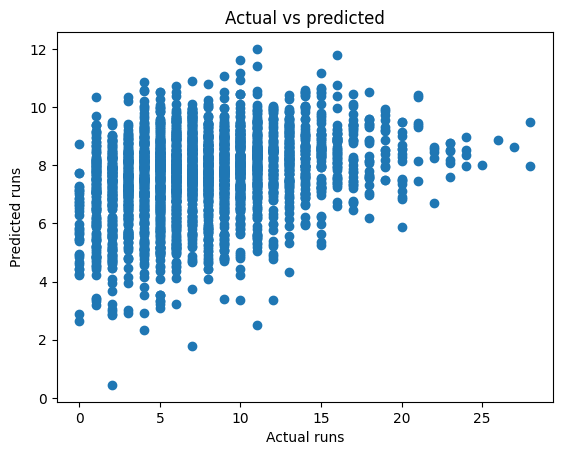

In [46]:
import matplotlib.pyplot as plt

plt.scatter(Y_test,Y_pred)
plt.xlabel("Actual runs")
plt.ylabel("Predicted runs")
plt.title("Actual vs predicted")
plt.show()


In [47]:
print(Y_pred[:10])

[8.27265291 9.9353657  8.47670907 7.17646943 6.42737647 8.07807475
 8.21718301 8.35753178 7.92507772 7.68413543]


In [ ]:

comparison.head(30)import pandas as pd
comparison=pd.DataFrame({
    "Actual":Y_test.values,
    "Predicted":Y_pred
})


,Actual,Predicted
0,9,8.272653
1,7,9.935366
2,6,8.476709
3,10,7.176469
4,8,6.427376
5,1,8.078075
6,13,8.217183
7,10,8.357532
8,3,7.925078
9,14,7.684135


In [49]:
comparison.sort_values(by="Actual").head(30)

,Actual,Predicted
68,0,4.214618
940,0,6.731192
76,0,7.301255
723,0,5.795960
2469,0,7.090642
2217,0,4.276429
2981,0,7.020155
2506,0,8.721311
608,0,7.722862
2557,0,5.618885


In [51]:
import os
os.makedirs("../../Models",exist_ok=True)

In [52]:
import joblib
joblib.dump(model,"../../Models/baseline_model.pkl")

['../../Models/baseline_model.pkl']

### Baseline model results 
-Model :Linear regression 
-Mse-18.26468298862668
-Observation:Linear fit is simple and should probably underfit complex patterns.

In [50]:
print(X_train.shape,X_test.shape)
print(Y_pred[:5])
print(Y_test.values[:5])

(12255, 81) (3064, 81)
[8.27265291 9.9353657  8.47670907 7.17646943 6.42737647]
[ 9  7  6 10  8]


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

model=LinearRegression()
scores=cross_val_score(
    model,
    X,
    Y,
    cv=5,
    scoring='neg_mean_squared_error'
)
mse_scores=-scores

print("MSE per fold:",mse_scores)
print("Average_MSE:",mse_scores.mean())
print("Std Dev:",mse_scores.std())

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score

train_pred=model.predict(X_train)
test_pred=model.predict(X_test)

train_mse=mean_squared_error(Y_train,train_pred)
test_mse=mean_squared_error(Y_test,test_pred)
R2_Score=r2_score(Y_test,Y_train)

print("Train MSE:",train_mse)
print("Test MSE:",test_mse)
print("R2_Score:",R2_Score)

In [ ]:
results=X_test.copy()

test_pred=model.predict(X_test)
results['actual']=Y_test
results['predicted']=test_pred
results['error']=abs(results['actual']-results['predicted'])

venue_errors=(
    results.groupby('venue')['error'].mean().sort_values(ascending=False)
)
print(venue_errors)


In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_size,train_scores,val_scores=learning_curve(
    estimator=model,
    x=X,
    y=Y,
    cv=5,
    scoring='neg_mean_squared_error',
    train_size=np.linspace(0.1,1.0,10),
    n_jobs=-1
)
train_error=-train_scores.mean(axis=1)
val_error=-val_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_size,train_error,marker='o',label='Training_Error')
plt.plot(train_size,val_error,marker='s',label='Validation_Error')
plt.xlabel=("Training Examples")
plt.ylabel=("MSE")
plt.title=("Learning Curve-IPL POWERPLAY PREDICTOR")
plt.legend()
plt.grid(True)

plt.show()


## Analysisng IPL Powerplay overs (1-6)
 OBJECTIVE:---->
## Analysing runs and wickets pattern in powerplay overs(1-6)
